In [1]:
from functions import *
import os
import matplotlib.pyplot as plt
import corner
import matplotlib.gridspec as gridspec
import h5py
import matplotlib
from mpl_toolkits.axes_grid.inset_locator import inset_axes

%matplotlib widget


/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/cbook/deprecation.py:107: MatplotlibDeprecationWarning: The mpl_toolkits.axes_grid module was deprecated in version 2.1. Use mpl_toolkits.axes_grid1 and mpl_toolkits.axisartist provies the same functionality instead.
  warnings.warn(message, mplDeprecation, stacklevel=1)


-

-

-

-

Plot demonstrating eta and mdotBH distributions for various mstar values

-

-

-

-

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:207: RuntimeWarning: divide by zero encountered in log
/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:236: RuntimeWarning: divide by zero encountered in log


<module 'matplotlib.pyplot' from '/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/matplotlib/pyplot.py'>

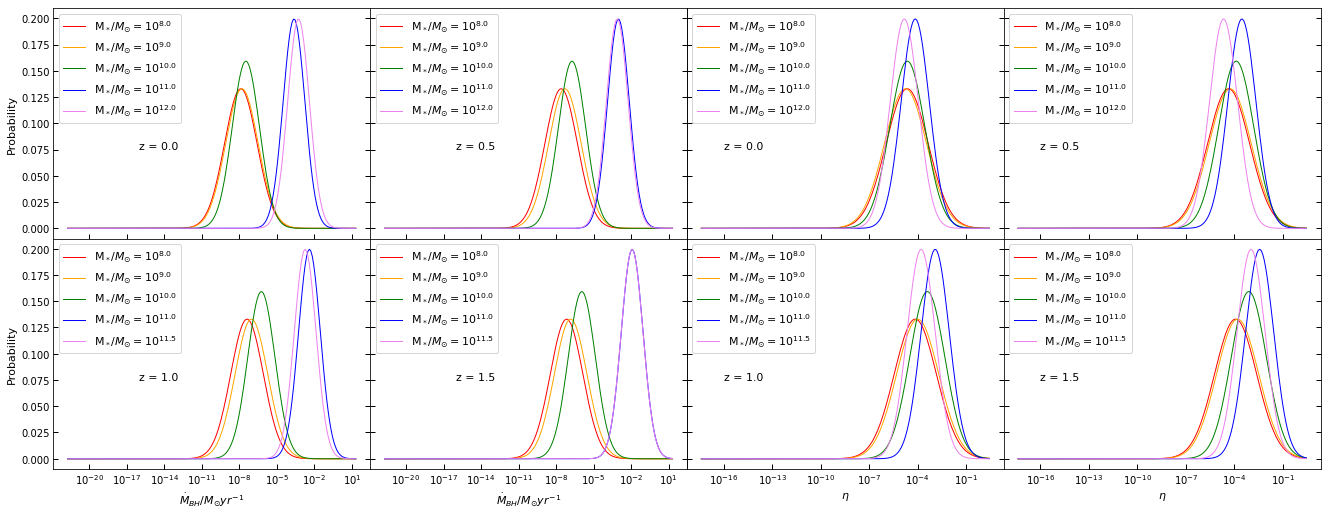

In [2]:
fig = plt.figure(figsize=(22,8))
zlist = [0.0, 0.5, 1.0, 1.5]
color = ['r','orange','green','blue','violet']
dlnMstar = 0.7
bins = 0.005
start = 10.0
siglnX = [3.0, 2.0]
fs = 11
tw = 1
tl = 5
lums = np.linspace(5,18,200)
textx = 10e-17
texty = 0.075

######### AXIS 1
ax1 = fig.add_axes([0.5, 0.5, 0.2, 0.4])

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[0], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdotedd = qlf.Mdot_mu_sig[:,2]
lneta = lnMdot - lnMdotedd

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-40, 1, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lneta[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax1.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax1.text(textx,texty,'z = '+str(zlist[0]), fontsize = fs)
ax1.set_xscale('log')
ax1.axis([np.e**x[0],np.e**x[-1], 0, max(y)+0.01])
ax1.legend(loc='upper left',fontsize = fs)
ax1.tick_params(direction='in', width = tw, length = tl, right = True)
plt.setp(ax1.get_xticklabels(), visible=False)

######### AXIS 2
ax2 = fig.add_axes([0.7, 0.5, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[1], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdotedd = qlf.Mdot_mu_sig[:,2]
lneta = lnMdot - lnMdotedd

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-40, 1, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lneta[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax2.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax2.text(textx,texty,'z = '+str(zlist[1]), fontsize = fs)  
ax2.legend(loc='upper left',fontsize = fs)
ax2.tick_params(direction='in', width = tw, length = tl, right = True)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)


######### AXIS 3
ax3 = fig.add_axes([0.5, 0.1, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[2], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdotedd = qlf.Mdot_mu_sig[:,2]
lneta = lnMdot - lnMdotedd

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-40, 1, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lneta[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax3.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax3.text(textx,texty,'z = '+str(zlist[2]), fontsize = fs)  
ax3.legend(loc='upper left',fontsize = fs)
ax3.tick_params(direction='in', width = tw, length = tl, right = True)
ax3.set_xlabel(r'$\eta$', fontsize = fs)


######### AXIS 4
ax4 = fig.add_axes([0.7, 0.1, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[3], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdotedd = qlf.Mdot_mu_sig[:,2]
lneta = lnMdot - lnMdotedd

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-40, 1, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lneta[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax4.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax4.text(textx,texty,'z = '+str(zlist[3]), fontsize = fs)  
ax4.legend(loc='upper left',fontsize = fs)
ax4.tick_params(direction='in', width = tw, length = tl, right = True)
ax4.set_xlabel(r'$\eta$', fontsize = fs)
plt.setp(ax4.get_yticklabels(), visible=False)



######### AXIS 1
ax1 = fig.add_axes([0.1, 0.5, 0.2, 0.4], sharey = ax4)

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[0], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax1.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax1.text(textx,texty,'z = '+str(zlist[0]), fontsize = fs) 
ax1.set_xscale('log')
ax1.axis([np.e**x[0],np.e**x[-1], 0, max(y)+0.01])
ax1.set_ylabel(r'Probability', fontsize = fs)  
ax1.legend(loc='upper left',fontsize = fs)
ax1.tick_params(direction='in', width = tw, length = tl, right = True)
plt.setp(ax1.get_xticklabels(), visible=False)

######### AXIS 2
ax2 = fig.add_axes([0.3, 0.5, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 12.0])
qlf = QLF(zlist[1], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax2.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax2.text(textx,texty,'z = '+str(zlist[1]), fontsize = fs)  
ax2.legend(loc='upper left',fontsize = fs)
ax2.tick_params(direction='in', width = tw, length = tl, right = True)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)


######### AXIS 3
ax3 = fig.add_axes([0.1, 0.1, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[2], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax3.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax3.text(textx,texty,'z = '+str(zlist[2]), fontsize = fs)  
ax3.legend(loc='upper left',fontsize = fs)
ax3.tick_params(direction='in', width = tw, length = tl, right = True)
ax3.set_xlabel(r'$\dot{M}_{BH}/M_{\odot} yr^{-1}$', fontsize = fs)
ax3.set_ylabel(r'Probability', fontsize = fs) 


######### AXIS 4
ax4 = fig.add_axes([0.3, 0.1, 0.2, 0.4], sharey = ax1, sharex = ax1)

smass = np.array([8.0, 9.0, 10.0, 11.0, 11.5])
qlf = QLF(zlist[3], bins)
stell = qlf.StellBins

qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)

lnMdot = qlf.Mdot_mu_sig[:,0]
sigs = qlf.Mdot_mu_sig[:,1]
lnMdot = np.log(np.e**lnMdot/(3.17098e-8*2e33))

for mass, c in zip(smass, color):
    i = np.argmin(np.abs(stell - mass))
    x = np.linspace(-50, 3, 200)
    A = 1
    y = ( A/np.sqrt(2.0 * np.pi * sigs[int(i)]**2.0) ) * np.exp( -(x - lnMdot[int(i)])**2.0 / (2.0 * sigs[int(i)]**2) )

    ax4.plot(np.e**x, y, color=c, lw= 1.0, label=r'M$_*/M_{\odot} = 10^{'+str(mass)+'}$')
ax4.text(textx,texty,'z = '+str(zlist[3]), fontsize = fs)  
ax4.legend(loc='upper left',fontsize = fs)
ax4.tick_params(direction='in', width = tw, length = tl, right = True)
ax4.set_xlabel(r'$\dot{M}_{BH}/M_{\odot} yr^{-1}$', fontsize = fs)
plt.setp(ax4.get_yticklabels(), visible=False)


plt
# plt.savefig('plots/paper-plots/Mdot-eta-distributions.pdf')

-

-

-

-

Plot displaying deconstructed QLF for low redshift values

-

-

-

-

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


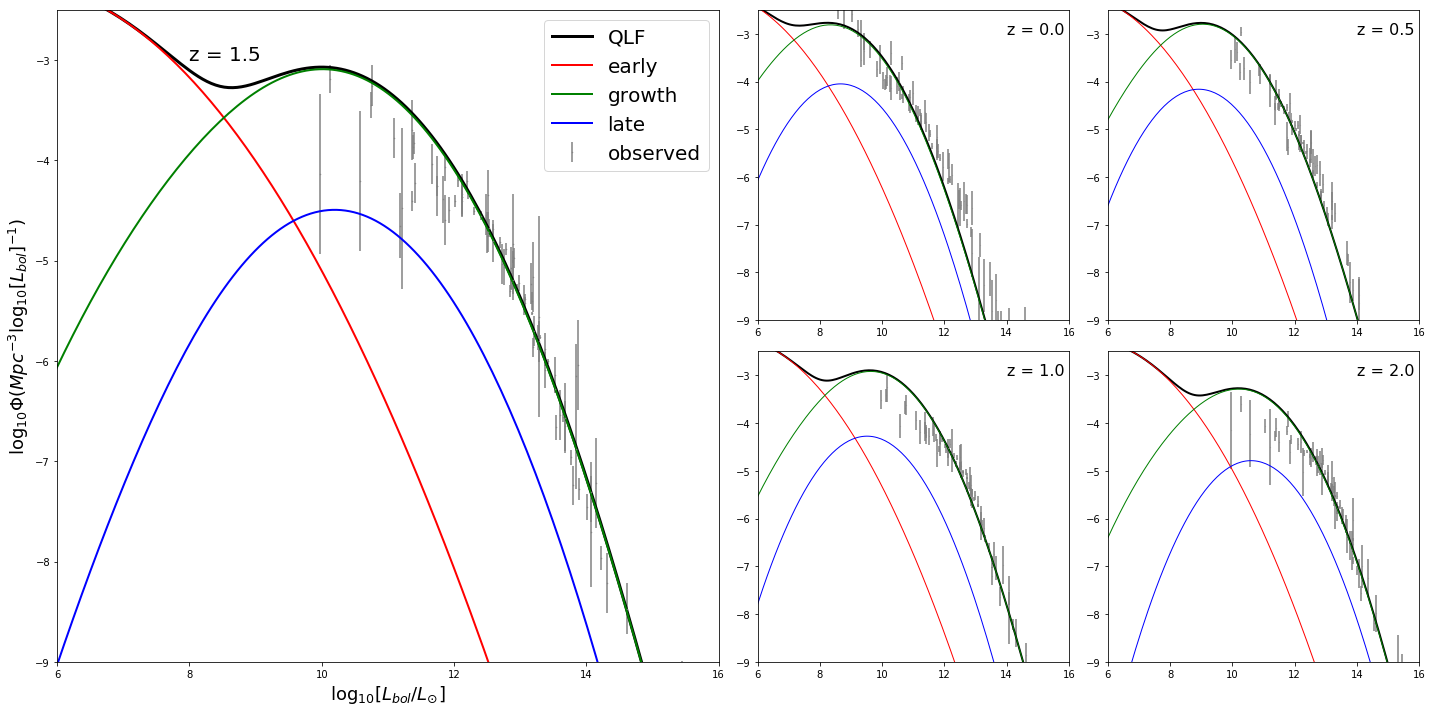

In [3]:
fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(2, 4)
lums = np.linspace(5,18,200)
z = 1.5
siglnX = [3.0, 2.0]
start = 10.0
ax1 = fig.add_subplot(gs[0:, 0:2])
qlf = QLF(z, 0.01)
qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)
xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
ax1.plot(xm, ym, c='k',lw=3, label='QLF')

totearly = []
totgrowth = []
totlate = []

for i in qlf.intvals:
    totearly.append(np.sum(i[qlf.pre]))
    totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
    totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

ax1.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r', label='early',lw=2)
ax1.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green', label='growth',lw=2)
ax1.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b', label='late',lw=2)


x, y , yerr = grab_obs(z)
ax1.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5, c='gray', label = 'observed')

ax1.axis([6,16,-9,-2.5])
ax1.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax1.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)
ax1.legend(fontsize = 20)
ax1.text(8,-3, 'z = '+str(z), fontsize = 20)


for z, i, j in zip([0.0,0.5,1.0,2.0],[0,0,1,1],[2,3,2,3]):
    ax = fig.add_subplot(gs[i, j], sharex = ax1, sharey = ax1)
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(start, approx_local=True)
    qlf.get_dNdlnL(lums, siglnX)
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k',lw=2)

    totearly = []
    totgrowth = []
    totlate = []

    for i in qlf.intvals:
        totearly.append(np.sum(i[qlf.pre]))
        totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
        totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

    ax.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r', label='early',lw=1)
    ax.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green', label='growth',lw=1)
    ax.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b', label='late',lw=1)


    x, y , yerr = grab_obs(z)
    ax.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
    ax.axis([6,16,-9,-2.5])
    ax.text(14,-3, 'z = '+str(z), fontsize = 16)
plt.tight_layout()
# plt.savefig('plots/paper-plots/QLF_eye-lowz.pdf')

-

-

-

-

Plot displaying deconstructed QLF for a lot of redshift values

-

-

-

-

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


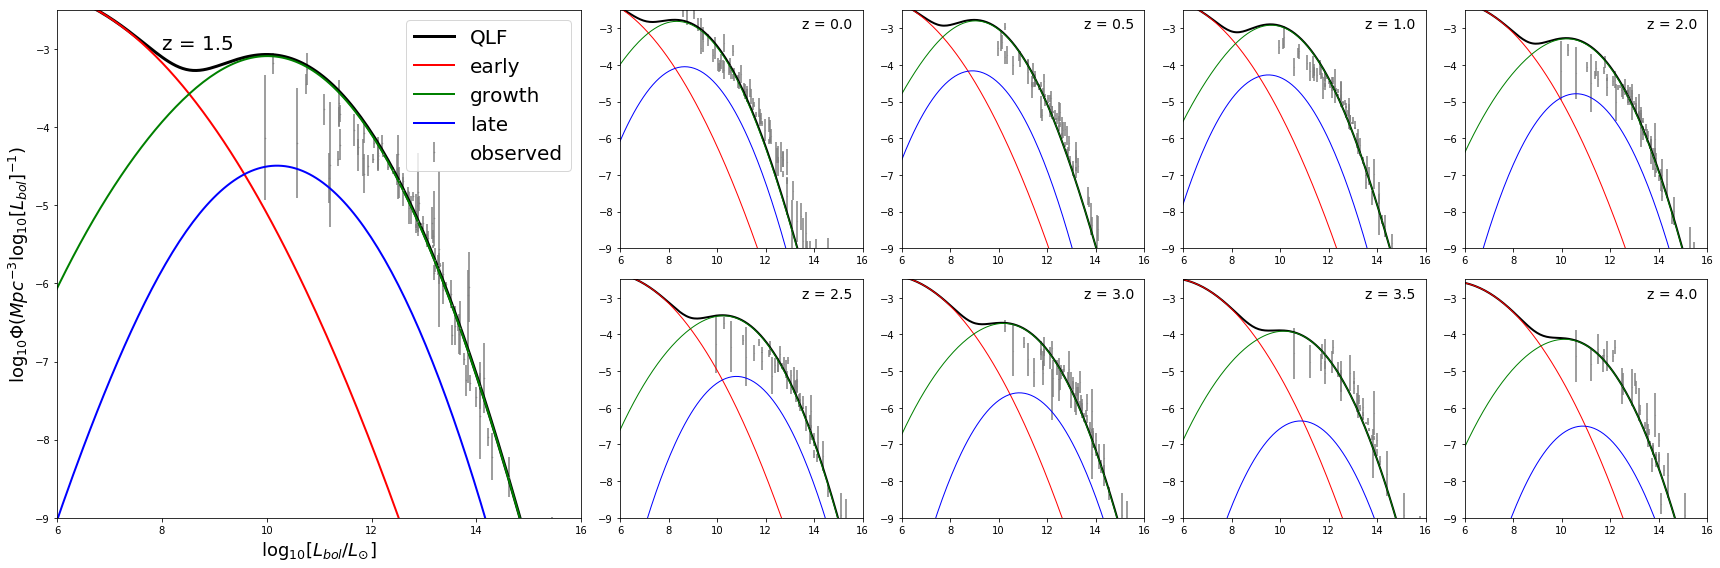

In [4]:
fig = plt.figure(figsize=(24,8))
gs = gridspec.GridSpec(2, 6)
lums = np.linspace(5,18,200)
z = 1.5
siglnX = [3.0, 2.0]
start = 10.0
ax1 = fig.add_subplot(gs[0:, 0:2])
qlf = QLF(z, 0.01)
qlf.get_dNdlnMstar(0.7)
qlf.get_Mbh(start, approx_local=True)
qlf.get_dNdlnL(lums, siglnX)
xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
ax1.plot(xm, ym, c='k',lw=3, label='QLF')

totearly = []
totgrowth = []
totlate = []

for i in qlf.intvals:
    totearly.append(np.sum(i[qlf.pre]))
    totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
    totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

ax1.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r', label='early',lw=2)
ax1.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green', label='growth',lw=2)
ax1.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b', label='late',lw=2)


x, y , yerr = grab_obs(z)
ax1.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5, c='gray', label = 'observed')

ax1.axis([6,16,-9,-2.5])
ax1.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax1.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)
ax1.legend(fontsize = 20)
ax1.text(8,-3, 'z = '+str(z), fontsize = 20)


for z, i, j in zip([0.0,0.5,1.0,2.0,2.5,3.0,3.5,4.0],[0,0,0,0,1,1,1,1],[2,3,4,5,2,3,4,5]):
    ax = fig.add_subplot(gs[i, j], sharex = ax1, sharey = ax1)
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(start, approx_local=True)
    qlf.get_dNdlnL(lums, siglnX)
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k',lw=2)

    totearly = []
    totgrowth = []
    totlate = []

    for i in qlf.intvals:
        totearly.append(np.sum(i[qlf.pre]))
        totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
        totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

    ax.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r', label='early',lw=1)
    ax.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green', label='growth',lw=1)
    ax.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b', label='late',lw=1)


    x, y , yerr = grab_obs(z)
    ax.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
    ax.axis([6,16,-9,-2.5])
    ax.text(13.5,-3, 'z = '+str(z), fontsize = 14)
plt.tight_layout()
# plt.savefig('plots/paper-plots/QLF_eye_lotz.pdf')

-

-

-

-

Plot attempting to demonstrate the effects of varrying parameters on individual regime contributions to the QLF

-

-

-

-

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:260: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:267: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


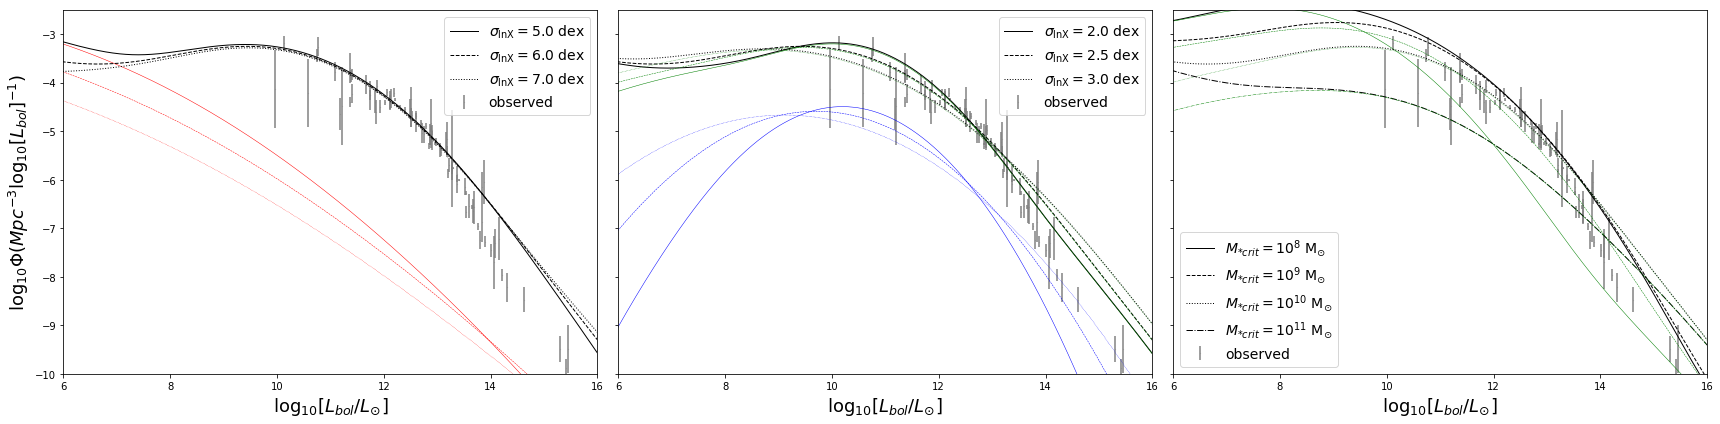

In [9]:
fig = plt.figure(figsize=(24,6))
gs = gridspec.GridSpec(1, 3)
lums = np.linspace(5,18,1000)
z = 1.5
qlf = QLF(z, 0.01)
x, y , yerr = grab_obs(z)
lines = ['solid','dashed','dotted','dashdot']
ax = fig.add_subplot(gs[0, 0])
for xsig1, ls in zip([5.0,6.0,7.0], lines):
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(10, approx_local=True)
    qlf.get_dNdlnL(lums, [xsig1, 2.5])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax.plot(xm, ym, c='k',lw=1, label=r'$\sigma_{\ln \rmX} = $'+str(xsig1)+' dex', ls = ls)

    totearly = []
    totgrowth = []
    totlate = []

    for i in qlf.intvals:
        totearly.append(np.sum(i[qlf.pre]))
        totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
        totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

    ax.plot(xm, np.log10(np.asarray(totearly) * np.log(10)), c='r',lw=0.5, ls=ls)
ax.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax.legend(fontsize=14)
ax.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax.set_ylabel(r'$\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$', fontsize =18)
ax.axis([6,16,-10,-2.5])


ax1 = fig.add_subplot(gs[0, 1], sharex = ax, sharey = ax)
for xsig2, ls in zip([2.0, 2.5, 3.0], lines):
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(10, approx_local=True)
    qlf.get_dNdlnL(lums, [6.0, xsig2])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax1.plot(xm, ym, c='k',lw=1, label=r'$\sigma_{\ln \rmX} = $'+str(xsig2)+' dex', ls = ls)

    totearly = []
    totgrowth = []
    totlate = []

    for i in qlf.intvals:
        totearly.append(np.sum(i[qlf.pre]))
        totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
        totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

    ax1.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green',lw=0.5,ls=ls)
    ax1.plot(xm, np.log10(np.asarray(totlate) * np.log(10)), c='b',lw=0.5, ls=ls)
ax1.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax1.legend(fontsize=14)
ax1.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax1.axis([6,16,-10,-2.5])


ax2 = fig.add_subplot(gs[0, 2], sharex = ax, sharey = ax)
for start, ls in zip([8,9,10, 11], lines):
    qlf.get_dNdlnMstar(0.7)
    qlf.get_Mbh(start, approx_local=True)
    qlf.get_dNdlnL(lums, [6.0, 2.5])
    xm, ym = lums, np.log10(qlf.dNdlnL * np.log(10))
    ax2.plot(xm, ym, c='k', lw=1, label=r'$M_{*crit} = 10^{'+str(start)+'}$ M$_{\odot}$', ls = ls)

    totearly = []
    totgrowth = []
    totlate = []

    for i in qlf.intvals:
        totearly.append(np.sum(i[qlf.pre]))
        totgrowth.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] >= 1.05 * qlf.mmax]))
        totlate.append(np.sum(i[qlf.post][qlf.slopes[qlf.post] <= 1.05 * qlf.mmax]))

    ax2.plot(xm, np.log10(np.asarray(totgrowth) * np.log(10)), c='green',lw=0.5,ls=ls)

ax2.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .15, c='gray', label = 'observed')
ax2.legend(fontsize=14)
ax2.set_xlabel(r'$\log_{10} [L_{bol}/L_{\odot}]$', fontsize=18)
ax2.axis([6,16,-10,-2.5])

plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.tight_layout()
# plt.savefig('plots/paper-plots/free_param_effects.pdf')

-

-

-

-

What was I trying to do with this plot?

-

-

-

-

/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:214: RuntimeWarning: divide by zero encountered in log
  mu_lnMdotbh = mu_lnX + np.log(Mdotbh)
/Users/megantillman/Documents/research/CIERA/QLF_project/get_QLF/functions.py:218: RuntimeWarning: divide by zero encountered in log
  return mu_lnMdotbh, lnMdotsig, np.log(Mdotedd), np.log(Mdotbh), np.log(sbhr), np.log(ssfr)


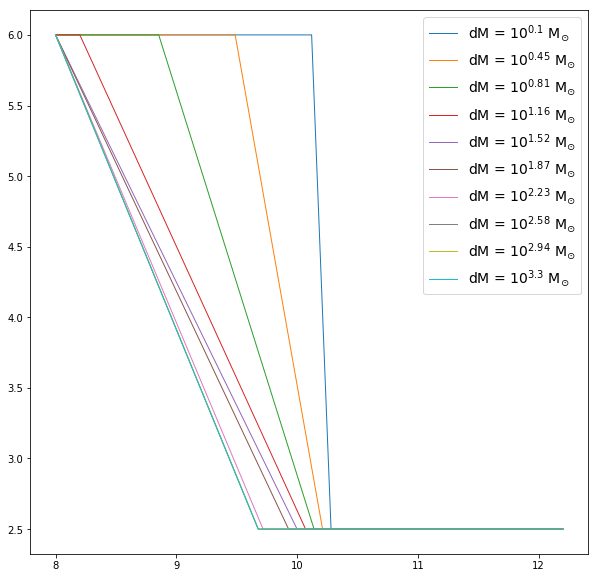

In [3]:
fig = plt.figure(figsize=(10,10))
lums = np.linspace(6,18,500)
for dM in np.linspace(0.1,3.3,10):
    qlf = QLF(z, 0.01)
    qlf.get_dNdlnMstar(0.7)
    qlf.get_SMBM(dM)
    qlf.get_dNdlnL(lums, [6.0, 2.5])
    Mdotbh = qlf.Mdot_mu_sig[:,0]
    plt.plot(qlf.StellBins, qlf.Mdot_mu_sig[:,1], lw=1, label=r'dM = $10^{'+str(dM)[0:4]+'}$ M$_{\odot}$')
    plt.legend(fontsize=14)

-

-

-

-

Plot for pre-disk post-disk chi2 grid comparison

-

-

-

-

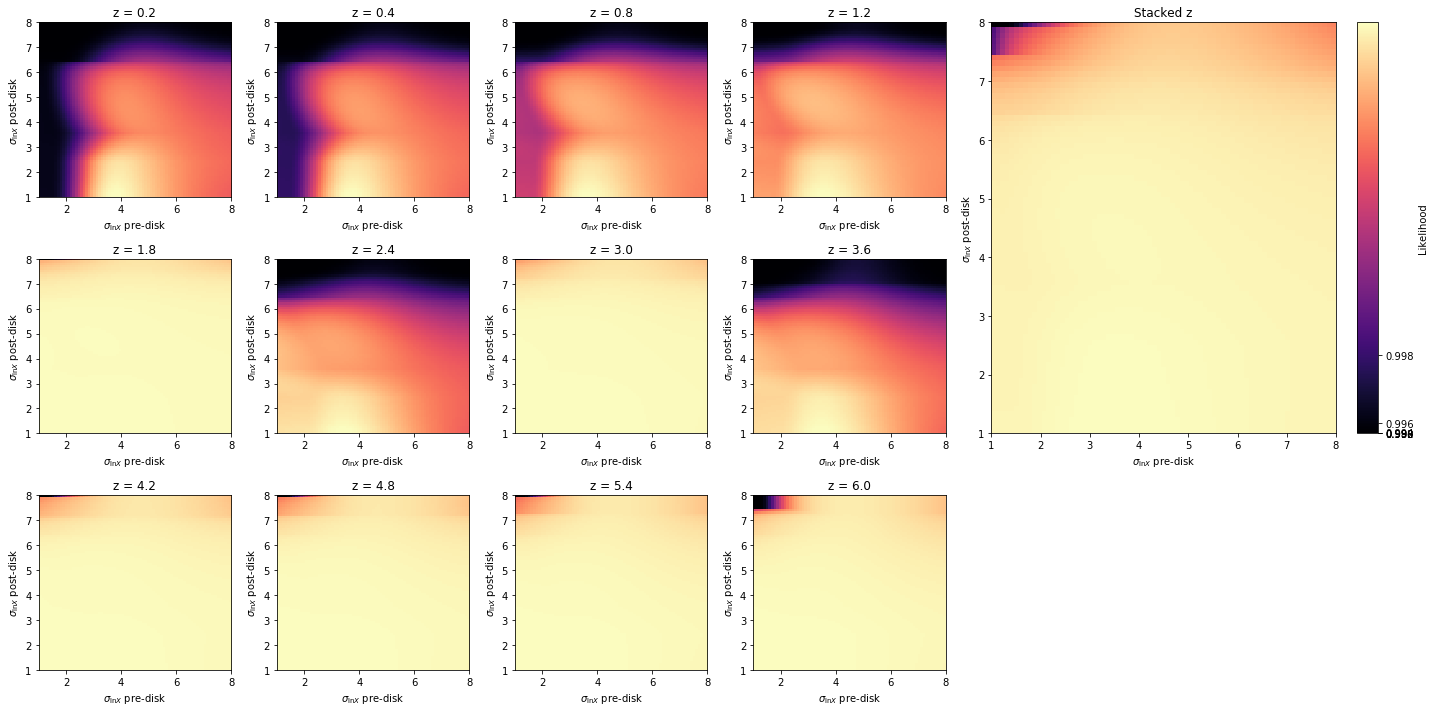

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import matplotlib.gridspec as gridspec
import matplotlib
# plt.close('all')

f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

prepost = True
prelogMstar0 = False
postlogMstar0 = False

# prepost = False
# prelogMstar0 = True
# postlogMstar0 = False

# prepost = False
# prelogMstar0 = False
# postlogMstar0 = True

fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 6)
stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,1,1,1,1,2,2,2,2],[0,1,2,3,0,1,2,3,0,1,2,3]):

    f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
    chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
    f.close()
    
    ax = fig.add_subplot(gs[i, j])
    
    #dM stuff
    Mchi2 = np.sum(chi23d, axis = (2,1))
#     maxM = max(Mchi2)
    maxM = sum(Mchi2)
    Mlike = np.e**(-Mchi2/maxM)
    
    #post stuff
    POchi2 = np.sum(chi23d, axis = (0,2))
#     maxPO = max(POchi2)
    maxPO = sum(POchi2)
    POlike = np.e**(-POchi2/maxPO)
    
    #pre stuff
    PRchi2 = np.sum(chi23d, axis = (0,1))
#     maxPR = max(PRchi2)
    maxPR = sum(PRchi2)
    PRlike = np.e**(-PRchi2/maxPR)
    
    #post-pre stuff
    if prepost == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 0))
#         maxV = max([maxPO,maxPR])
        maxV = maxPO+maxPR
        like = np.e**(-grid2d/maxV)
        xlabel = r'$\sigma_{\ln{X}}$ pre-disk'
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        file = 'pre-disk_vs_post-disk'
        axis = [1,8,1,8]
        extent = [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]
        
    elif prelogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 2))
#         maxV = max([maxPR,maxM])
        maxV = maxPR + maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ pre-disk'
        xlabel = 'logMstar0'
        file = 'pre-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX1[-1], siglnX1[0]]
        
    elif postlogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 1))
#         maxV = max([maxPO,maxM])
        maxV = maxPO+maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = 'logMstar0'
        file = 'post-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX2[-1], siglnX2[0]]

        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis(axis)
    img = ax.imshow(like, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
    ax.set_title('z = '+str(z))
    stack += like / len(zlist)
       
        

ax1 = fig.add_subplot(gs[0:2,4:])
total = ax1.imshow(stack, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
ax1.axis(axis)
ax1.set_title('Stacked z')
ax1.set_ylabel(ylabel)
ax1.set_xlabel(xlabel)
plt.tight_layout()
cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05)
# plt.savefig('plots/general-plots/chi2_3pShenFit_nw'+file+'.pdf')



-

-

-

-

Plot for Mstarcrit predisk chi2 grid comparison

-

-

-

-

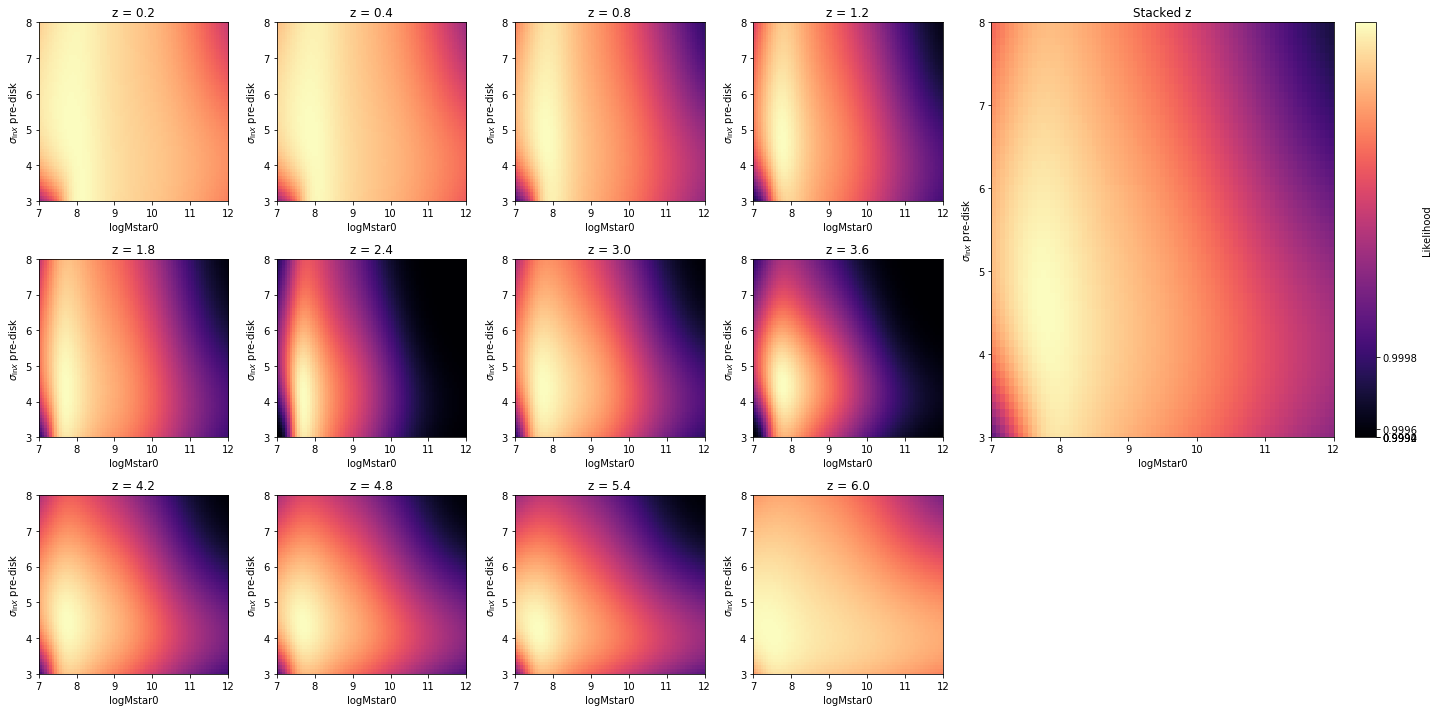

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import matplotlib.gridspec as gridspec
import matplotlib
# plt.close('all')

f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

# prepost = True
# prelogMstar0 = False
# postlogMstar0 = False

prepost = False
prelogMstar0 = True
postlogMstar0 = False

# prepost = False
# prelogMstar0 = False
# postlogMstar0 = True

fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 6)
stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,1,1,1,1,2,2,2,2],[0,1,2,3,0,1,2,3,0,1,2,3]):

    f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
    chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
    f.close()
    
    ax = fig.add_subplot(gs[i, j])
    
    #dM stuff
    Mchi2 = np.sum(chi23d, axis = (2,1))
#     maxM = max(Mchi2)
    maxM = sum(Mchi2)
    Mlike = np.e**(-Mchi2/maxM)
    
    #post stuff
    POchi2 = np.sum(chi23d, axis = (0,2))
#     maxPO = max(POchi2)
    maxPO = sum(POchi2)
    POlike = np.e**(-POchi2/maxPO)
    
    #pre stuff
    PRchi2 = np.sum(chi23d, axis = (0,1))
#     maxPR = max(PRchi2)
    maxPR = sum(PRchi2)
    PRlike = np.e**(-PRchi2/maxPR)
    
    #post-pre stuff
    if prepost == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 0))
#         maxV = max([maxPO,maxPR])
        maxV = maxPO+maxPR
        like = np.e**(-grid2d/maxV)
        xlabel = r'$\sigma_{\ln{X}}$ pre-disk'
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        file = 'pre-disk_vs_post-disk'
        axis = [1,8,1,8]
        extent = [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]
        
    elif prelogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 2))
#         maxV = max([maxPR,maxM])
        maxV = maxPR + maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ pre-disk'
        xlabel = 'logMstar0'
        file = 'pre-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX1[-1], siglnX1[0]]
        
    elif postlogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 1))
#         maxV = max([maxPO,maxM])
        maxV = maxPO+maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = 'logMstar0'
        file = 'post-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX2[-1], siglnX2[0]]

        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis(axis)
    img = ax.imshow(like, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
    ax.set_title('z = '+str(z))
    stack += like / len(zlist)
       
        

ax1 = fig.add_subplot(gs[0:2,4:])
total = ax1.imshow(stack, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
ax1.axis(axis)
ax1.set_title('Stacked z')
ax1.set_ylabel(ylabel)
ax1.set_xlabel(xlabel)
plt.tight_layout()
cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05)
# plt.savefig('plots/general-plots/chi2_3pShenFit_nw'+file+'.pdf')



-

-

-

-

Plot for mstarcrit postdisk chi2 grid comparisons

-

-

-

-

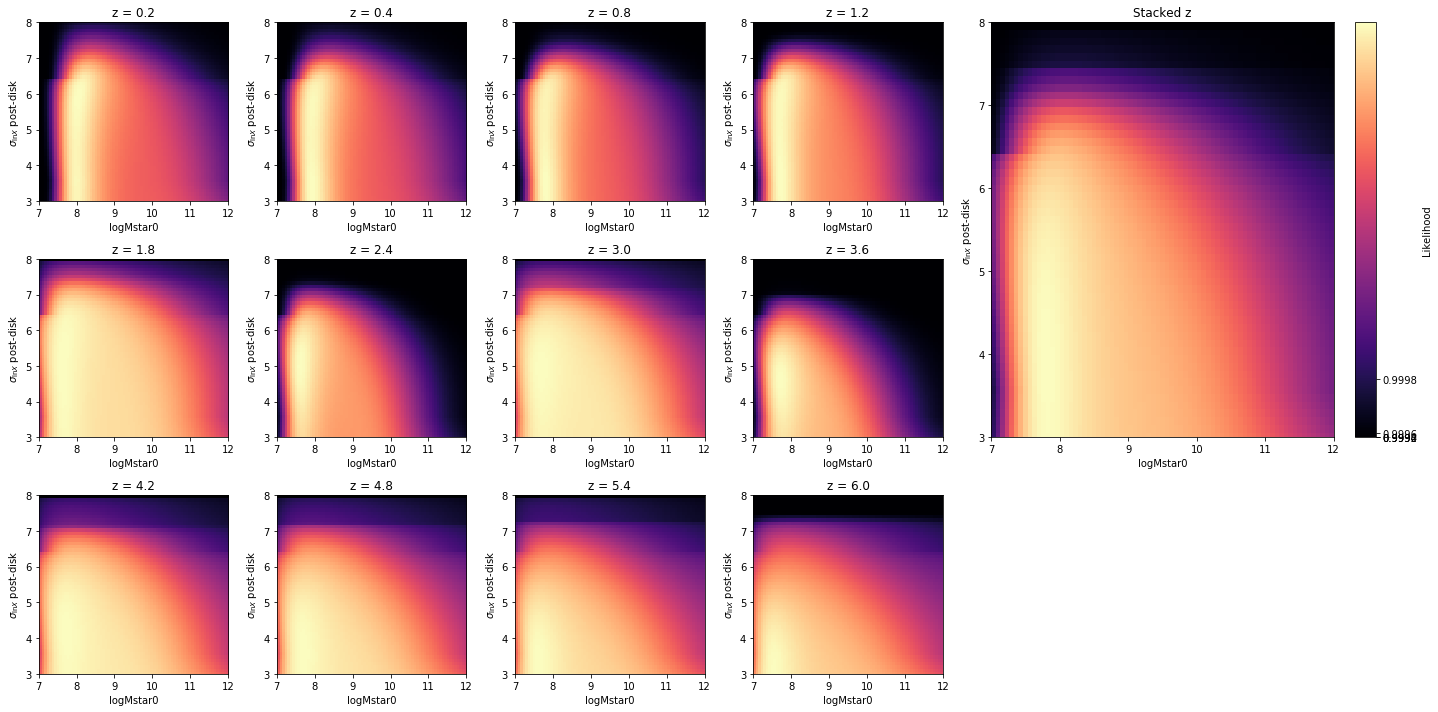

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import matplotlib.gridspec as gridspec
import matplotlib
# plt.close('all')

f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

# prepost = True
# prelogMstar0 = False
# postlogMstar0 = False

# prepost = False
# prelogMstar0 = True
# postlogMstar0 = False

prepost = False
prelogMstar0 = False
postlogMstar0 = True

fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 6)
stack = np.zeros((len(logMstar0 ), len(logMstar0 )))
zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,1,1,1,1,2,2,2,2],[0,1,2,3,0,1,2,3,0,1,2,3]):

    f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
    chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
    f.close()
    
    ax = fig.add_subplot(gs[i, j])
    
    #dM stuff
    Mchi2 = np.sum(chi23d, axis = (2,1))
#     maxM = max(Mchi2)
    maxM = sum(Mchi2)
    Mlike = np.e**(-Mchi2/maxM)
    
    #post stuff
    POchi2 = np.sum(chi23d, axis = (0,2))
#     maxPO = max(POchi2)
    maxPO = sum(POchi2)
    POlike = np.e**(-POchi2/maxPO)
    
    #pre stuff
    PRchi2 = np.sum(chi23d, axis = (0,1))
#     maxPR = max(PRchi2)
    maxPR = sum(PRchi2)
    PRlike = np.e**(-PRchi2/maxPR)
    
    #post-pre stuff
    if prepost == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 0))
#         maxV = max([maxPO,maxPR])
        maxV = maxPO+maxPR
        like = np.e**(-grid2d/maxV)
        xlabel = r'$\sigma_{\ln{X}}$ pre-disk'
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        file = 'pre-disk_vs_post-disk'
        axis = [1,8,1,8]
        extent = [siglnX1[0], siglnX1[-1], siglnX2[-1], siglnX2[0]]
        
    elif prelogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 2))
#         maxV = max([maxPR,maxM])
        maxV = maxPR + maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ pre-disk'
        xlabel = 'logMstar0'
        file = 'pre-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX1[-1], siglnX1[0]]
        
    elif postlogMstar0 == True:
        grid2d = np.transpose(np.sum(chi23d, axis = 1))
#         maxV = max([maxPO,maxM])
        maxV = maxPO+maxM
        like = np.e**(-grid2d/maxV)
        ylabel = r'$\sigma_{\ln{X}}$ post-disk'
        xlabel = 'logMstar0'
        file = 'post-disk_vs_logMstar0'
        axis = [7,12,3,8]
        extent = [logMstar0 [0], logMstar0 [-1], siglnX2[-1], siglnX2[0]]

        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis(axis)
    img = ax.imshow(like, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
    ax.set_title('z = '+str(z))
    stack += like / len(zlist)
       
        

ax1 = fig.add_subplot(gs[0:2,4:])
total = ax1.imshow(stack, cmap = 'magma', interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.PowerNorm(gamma=10))
ax1.axis(axis)
ax1.set_title('Stacked z')
ax1.set_ylabel(ylabel)
ax1.set_xlabel(xlabel)
plt.tight_layout()
cbar = plt.colorbar(total, label=r'Likelihood', pad = 0.05)
# plt.savefig('plots/general-plots/chi2_3pShenFit_nw'+file+'.pdf')



-

-

-

-

Plot for postdisk Mstarcrit comparison at the most probable value of predisk

-

-

-

-

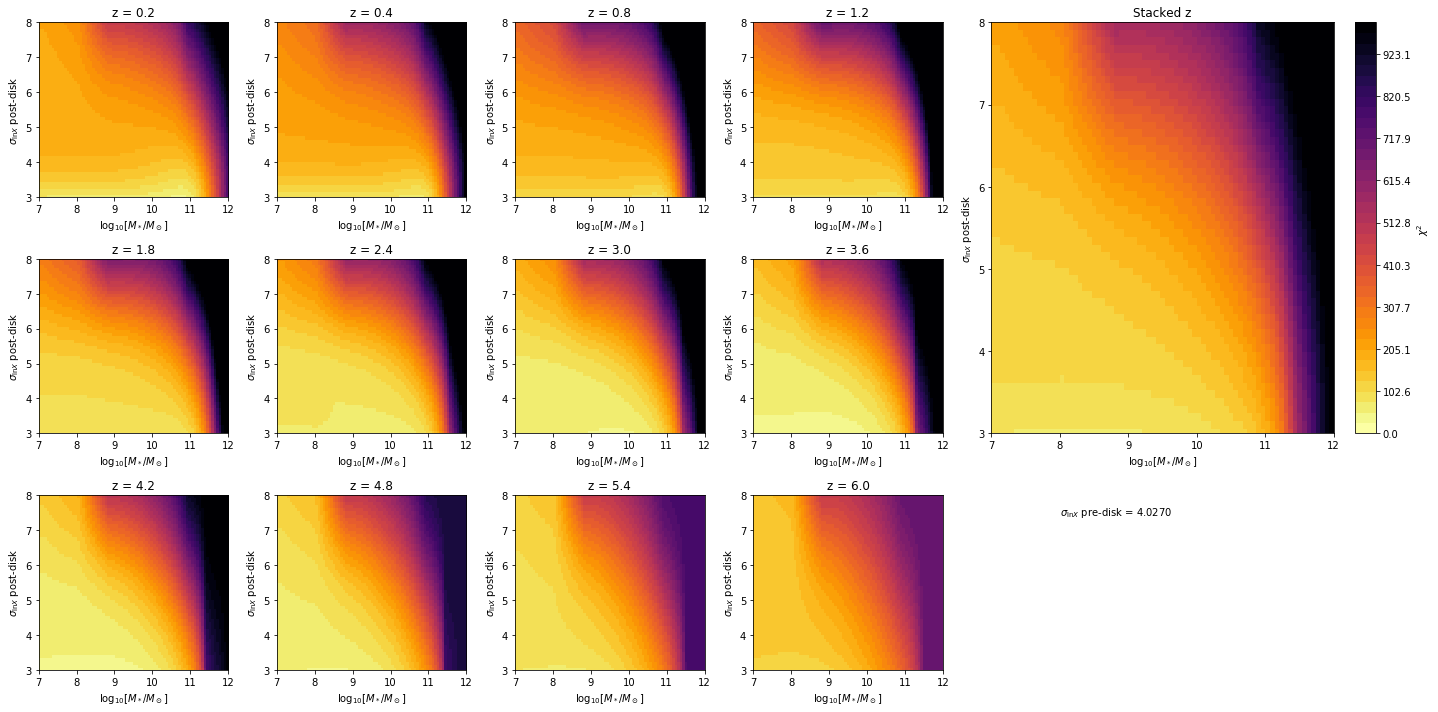

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import matplotlib.gridspec as gridspec
import matplotlib

f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
logMstar0 = f['logMstar0'][:]
siglnX2 = f['siglnX2'][:]
siglnX1 = f['siglnX1'][:]
f.close()

fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(3, 6)
stack = np.zeros((len(logMstar0 ), len(logMstar0 )))

pred = np.sum(chi23d, axis=(0,2))
minpre =  min(np.sum(chi23d, axis=(0,2)))
prein = np.where(pred == minpre)[0][0]

zlist = [0.2, 0.4, 0.8, 1.2, 1.8, 2.4, 3.0, 3.6, 4.2, 4.8, 5.4, 6.0]
for z, i, j in zip(zlist,[0,0,0,0,1,1,1,1,2,2,2,2],[0,1,2,3,0,1,2,3,0,1,2,3]):

    f = h5py.File("QUEST/data/chi2_3pShenfit_nw.h5py", "r")
    chi23d = np.transpose(f['z='+str(z)+'/chi23d_grid'][:])
    f.close()
    
    ax = fig.add_subplot(gs[i, j])
    
    #dM stuff
    Mchi2 = np.sum(chi23d, axis = (2,1))
    maxM = sum(Mchi2)
    Mlike = np.e**(-Mchi2/maxM)
    
    #post stuff
    POchi2 = np.sum(chi23d, axis = (0,2))
    maxPO = sum(POchi2)
    POlike = np.e**(-POchi2/maxPO)
    

    grid2d = np.transpose(np.sum(chi23d, axis = 1))
    maxV = maxPO+maxM
    like = np.e**(-grid2d)
    ylabel = r'$\sigma_{\ln{X}}$ post-disk'
    xlabel = r'$\log_{10} [M_*/M_\odot]$'
    file = 'post-disk_vs_logMstar0'
    axis = [7,12,3,8]
    extent = [logMstar0 [0], logMstar0 [-1], siglnX2[-1], siglnX2[0]]

    cmap = 'cubehelix_r'
    cmap = 'inferno_r'
    grid2d = chi23d[:,prein,:]
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis(axis)
    img = ax.imshow(grid2d, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.BoundaryNorm(boundaries=np.linspace(0,1000,40), ncolors=256))
    ax.set_title('z = '+str(z))
    stack += (grid2d) / len(zlist)
    
#     plt.text(8,2,'$\sigma_{\ln{X}}$ pre-disk = '+str(siglnX1[prein])[:6])

pred = np.sum(chi23d, axis=(0,2))
minpre =  min(np.sum(chi23d, axis=(0,2)))

ax1 = fig.add_subplot(gs[0:2,4:])
total = ax1.imshow(stack, cmap = cmap, interpolation = 'nearest', aspect='auto', extent = extent, norm=matplotlib.colors.BoundaryNorm(boundaries=np.linspace(0,1000,40), ncolors=256))
ax1.axis(axis)
ax1.set_title('Stacked z')
ax1.set_ylabel(ylabel)
ax1.set_xlabel(xlabel)
plt.tight_layout()
cbar = plt.colorbar(total, label=r'$\chi ^2$ ', pad = 0.05)
plt.text(8,2,'$\sigma_{\ln{X}}$ pre-disk = '+str(siglnX1[prein])[:6])
plt.savefig('plots/general-plots/chi2_ShenFit_nw'+file+'.pdf')

